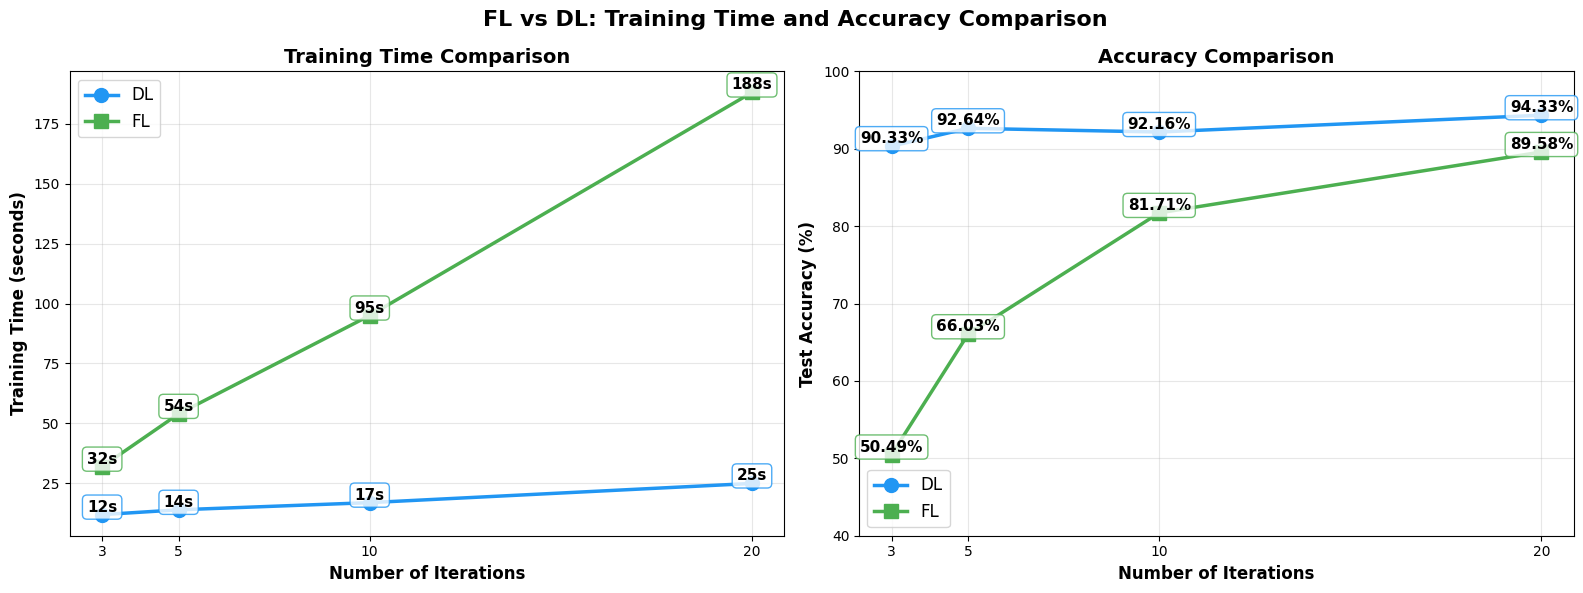


✅ Training time and accuracy comparison plot saved as 'fl_dl_time_accuracy_comparison.png'


In [4]:
import matplotlib.pyplot as plt
# Experimental results data
iterations = [3, 5, 10, 20]

# Training times in seconds
dl_times = [12, 14, 17, 25]
fl_times = [32, 54, 95, 188]  # 32s, 54s, 1m35s=95s, 3m8s=188s

# Accuracies
dl_accuracies = [90.33, 92.64, 92.16, 94.33]
fl_accuracies = [50.49, 66.03, 81.71, 89.58]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FL vs DL: Training Time and Accuracy Comparison', fontsize=16, fontweight='bold')

# Plot 1: Training Time Comparison
ax1.plot(iterations, dl_times, marker='o', linewidth=2.5, markersize=10, 
         label='DL', color='#2196F3', linestyle='-')
ax1.plot(iterations, fl_times, marker='s', linewidth=2.5, markersize=10, 
         label='FL', color='#4CAF50', linestyle='-')

# Add value labels on points for training time
for i, (it, dl_t, fl_t) in enumerate(zip(iterations, dl_times, fl_times)):
    ax1.text(it, dl_t, f'{dl_t}s', ha='center', va='bottom', fontweight='bold', fontsize=11, 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2196F3', alpha=0.8))
    ax1.text(it, fl_t, f'{fl_t}s', ha='center', va='bottom', fontweight='bold', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#4CAF50', alpha=0.8))

ax1.set_xlabel('Number of Iterations', fontsize=12, fontweight='bold')
ax1.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(iterations)

# Plot 2: Accuracy Comparison
ax2.plot(iterations, dl_accuracies, marker='o', linewidth=2.5, markersize=10, 
         label='DL', color='#2196F3', linestyle='-')
ax2.plot(iterations, fl_accuracies, marker='s', linewidth=2.5, markersize=10, 
         label='FL', color='#4CAF50', linestyle='-')

# Add value labels on points for accuracy
for i, (it, dl_a, fl_a) in enumerate(zip(iterations, dl_accuracies, fl_accuracies)):
    ax2.text(it, dl_a, f'{dl_a:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2196F3', alpha=0.8))
    ax2.text(it, fl_a, f'{fl_a:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#4CAF50', alpha=0.8))

ax2.set_xlabel('Number of Iterations', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(iterations)
ax2.set_ylim([40, 100])

plt.tight_layout()
plt.savefig('fl_dl_time_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Training time and accuracy comparison plot saved as 'fl_dl_time_accuracy_comparison.png'")

In [3]:
import pandas as pd
# Create detailed comparison table
comparison_table = pd.DataFrame({
    'Iterations': iterations,
    'DL Time (seconds)': dl_times,
    'FL Time (seconds)': fl_times,
    'Time Ratio (FL/DL)': [f'{fl/dl:.1f}x' for fl, dl in zip(fl_times, dl_times)],
    'DL Accuracy (%)': dl_accuracies,
    'FL Accuracy (%)': fl_accuracies,
    'Accuracy Gap (%)': [round(dl - fl, 2) for dl, fl in zip(dl_accuracies, fl_accuracies)]
})

print("\n" + "="*100)
print("EXPERIMENTAL RESULTS: FL vs DL COMPARISON")
print("="*100)
print(comparison_table.to_string(index=False))
print("="*100)
print("\nKey Observations:")
print(f"• FL is {fl_times[-1]/dl_times[-1]:.1f}x slower than DL on average (20 iterations)")
print(f"• DL achieves {dl_accuracies[-1]:.2f}% accuracy vs FL's {fl_accuracies[-1]:.2f}% ({dl_accuracies[-1]-fl_accuracies[-1]:.2f}% gap)")
print(f"• FL requires more iterations to achieve competitive accuracy")
print(f"• At 20 iterations, FL approaches DL performance with only {dl_accuracies[-1]-fl_accuracies[-1]:.2f}% accuracy difference")


EXPERIMENTAL RESULTS: FL vs DL COMPARISON
 Iterations  DL Time (seconds)  FL Time (seconds) Time Ratio (FL/DL)  DL Accuracy (%)  FL Accuracy (%)  Accuracy Gap (%)
          3                 12                 32               2.7x            90.33            50.49             39.84
          5                 14                 54               3.9x            92.64            66.03             26.61
         10                 17                 95               5.6x            92.16            81.71             10.45
         20                 25                188               7.5x            94.33            89.58              4.75

Key Observations:
• FL is 7.5x slower than DL on average (20 iterations)
• DL achieves 94.33% accuracy vs FL's 89.58% (4.75% gap)
• FL requires more iterations to achieve competitive accuracy
• At 20 iterations, FL approaches DL performance with only 4.75% accuracy difference
